In [1]:
#Load packages
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import json
import csv

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])

def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the decimal/fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')  # Start of the year
    # Calculate the date by adding the fractional part as days
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

def basic_formatting( ax, spines=["bottom"], which="y", title=None, ylabel=None, xlabel=None, xsize=12, ysize=12, xlims=None, ylims=None ):
    """
    Specifies the basic formatting of all plots.
    """
    # Remove spines
    [ax.spines[j].set_visible( False ) for j in ax.spines if j not in spines]

    # Format axes ticks
    ax.tick_params( axis="x", bottom=False, which="both", labelbottom=True, labelsize=xsize, pad=0 )
    ax.tick_params( axis="y", left=False, which="both", labelleft=True, labelsize=ysize, pad=0 )

    # Label axes
    ax.set_xlabel( xlabel, fontsize=xsize )
    ax.set_ylabel( ylabel, fontsize=ysize )
    ax.set_title( title )

    ax.set_facecolor( "w" )

    # Add a simple grid
    ax.grid( which="both", axis=which, linewidth=1, color="#F1F1F1", zorder=1 )

    # Add the xlims
    if xlims:
        ax.set_xlim( xlims )
    if ylims:
        ax.set_ylim( ylims )

from countryinfo import CountryInfo

available_countries = CountryInfo().all()
# Define the regions that constitute the Americas
americas_continents = ['North America', 'South America', 'Central America', 'Caribbean']

sample = list(available_countries.values())[0]
print(sample.keys())
# Extract unique continents (optional)
unique_regions = set(
    country['region'] for country in available_countries.values() if 'region' in country
)
print("Unique Regions in Dataset:", unique_regions)

# Filter countries in the Americas and extract their names
americas_regions = ['Americas']  # This is the correct label used by your data

american_countries = [
    country['name'] for country in available_countries.values()
    if country.get('region') in americas_regions
]

print("\nCountries in the Americas:")
for name in american_countries:
    print(name)

/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


dict_keys(['name', 'altSpellings', 'area', 'borders', 'callingCodes', 'capital', 'capital_latlng', 'currencies', 'demonym', 'flag', 'geoJSON', 'ISO', 'languages', 'latlng', 'nativeName', 'population', 'provinces', 'region', 'subregion', 'timezones', 'tld', 'translations', 'wiki'])
Unique Regions in Dataset: {'', 'Oceania', 'Asia', 'Europe', 'Africa', 'Americas'}

Countries in the Americas:
Greenland
Montserrat
Panama
Bermuda
South Georgia
Saint Pierre and Miquelon
Brazil
Falkland Islands
Mexico
Dominica
United States
Martinique
Jamaica
Guatemala
Barbados
Suriname
Uruguay
Argentina
Grenada
Guyana
Saint Vincent and the Grenadines
Bolivia
Paraguay
Anguilla
Cayman Islands
Colombia
The Bahamas
Haiti
Canada
Saint Lucia
Cuba
Peru
Costa Rica
Saint Kitts and Nevis
Puerto Rico
Dominican Republic
French Guiana
Venezuela
Belize
Nicaragua
Chile
Guadeloupe
El Salvador
Ecuador
Aruba
Honduras
Antigua and Barbuda
Trinidad and Tobago


In [2]:
#TMRCA statistics

TMRCA = []

with open("/DENV/2024/D2/F1112/F112__markov_newseqs.aligned.log","r") as f:
    lines = [line for line in f if not line.startswith("#")]
    reader = csv.DictReader(lines, delimiter="\t")
    print(reader.fieldnames)
    for row in reader:
        mrca = float(row['age(root)'])
        TMRCA.append(mrca)

TMRCA_data = pd.DataFrame(TMRCA,columns=['TMRCA'])
#Filter data outside the HPD95
print(np.median(TMRCA_data['TMRCA']))
data = TMRCA_data['TMRCA']
hpdLo,hpdHi=hpd(data,0.95)
print(hpdLo,hpdHi)

['state', 'joint', 'prior', 'likelihood', 'age(root)', 'treeLength', 'location.clock.rate', 'location.meanRate', 'location.rates.Bangladesh.Bolivia', 'location.rates.Bangladesh.Brazil', 'location.rates.Bangladesh.Colombia', 'location.rates.Bangladesh.Ecuador', 'location.rates.Bangladesh.Paraguay', 'location.rates.Bangladesh.Peru', 'location.rates.Bangladesh.USA', 'location.rates.Bangladesh.Other', 'location.rates.Bolivia.Brazil', 'location.rates.Bolivia.Colombia', 'location.rates.Bolivia.Ecuador', 'location.rates.Bolivia.Paraguay', 'location.rates.Bolivia.Peru', 'location.rates.Bolivia.USA', 'location.rates.Bolivia.Other', 'location.rates.Brazil.Colombia', 'location.rates.Brazil.Ecuador', 'location.rates.Brazil.Paraguay', 'location.rates.Brazil.Peru', 'location.rates.Brazil.USA', 'location.rates.Brazil.Other', 'location.rates.Colombia.Ecuador', 'location.rates.Colombia.Paraguay', 'location.rates.Colombia.Peru', 'location.rates.Colombia.USA', 'location.rates.Colombia.Other', 'location.r

<Axes: xlabel='TMRCA', ylabel='Density'>

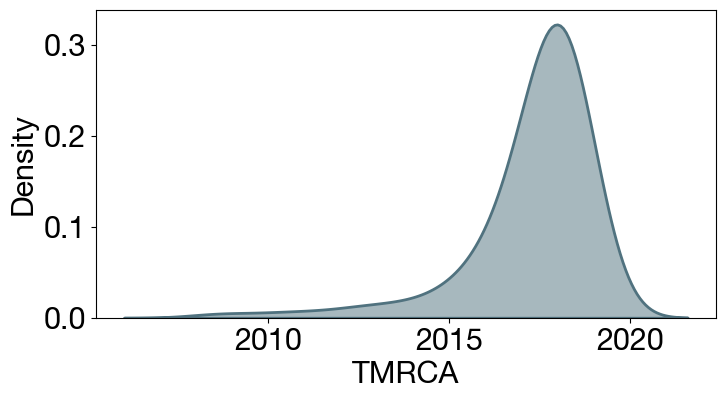

In [3]:
#Plot density plot with seaborn
#compute density
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.stats import norm

from sklearn.neighbors import KernelDensity


# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 4), facecolor='w', frameon=False)

# Plot the data
TMRCA_data_filtered = TMRCA_data[(TMRCA_data['TMRCA'] >= hpdLo) & (TMRCA_data['TMRCA'] <= hpdHi)]
sns.kdeplot(x=TMRCA_data_filtered['TMRCA'], color='#50727F', linewidth=2, fill=True, alpha=0.5, bw_adjust=3, ax=ax)


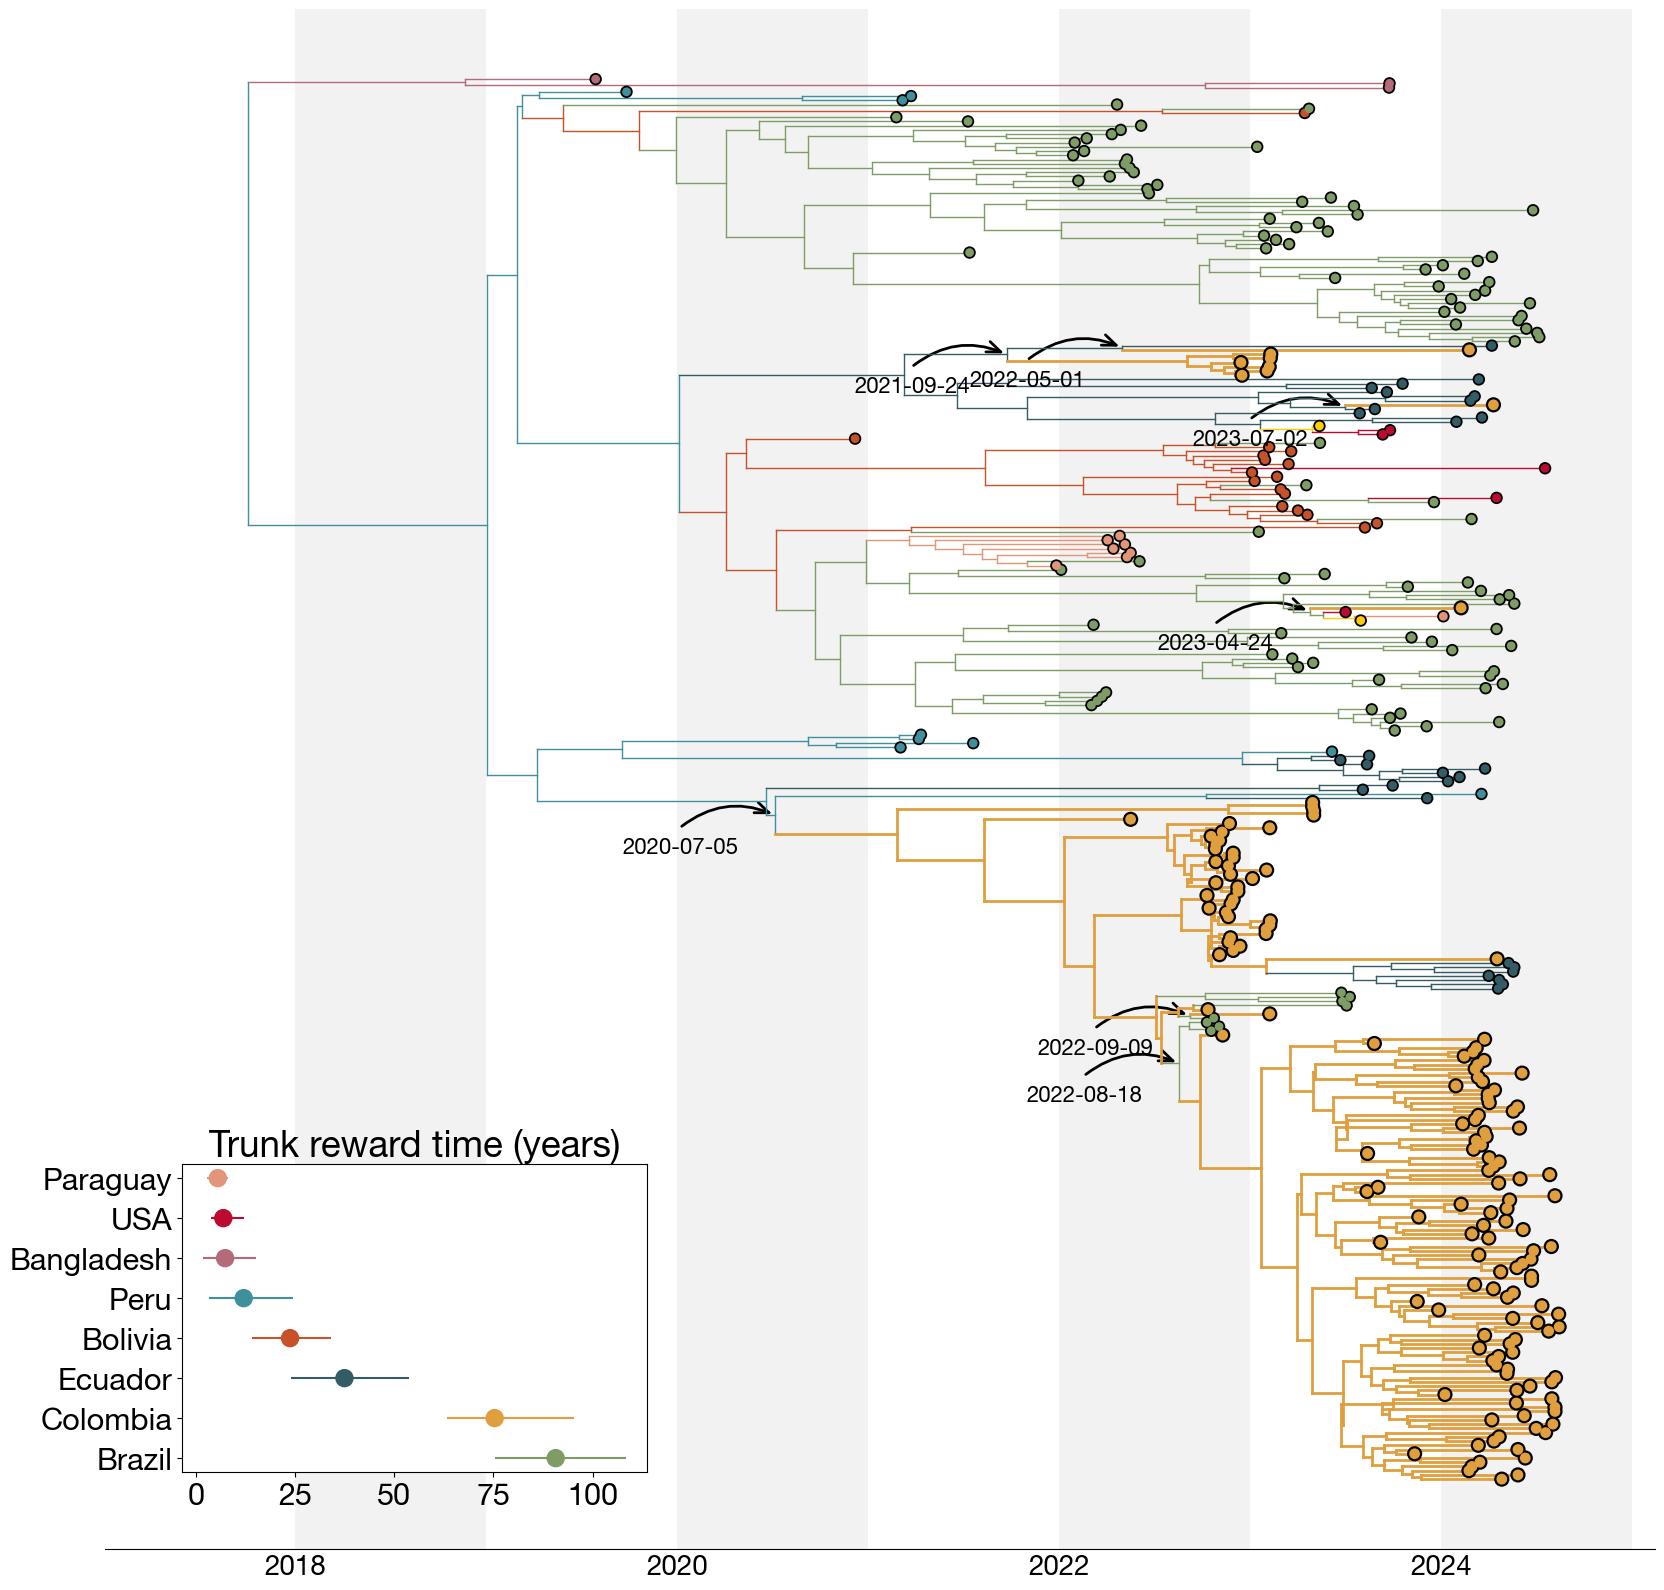

In [4]:
import baltic as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch

# Load the tree
treePath = '/DENV/2024/D2/F1112/newMCCTree_F1112_Markov.mcc.tree'
ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

# Define color and label dictionaries
colors = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade"
}

# Function to detect introductions into Colombia
def introductions_into_colombia(k):
    return 'location.rate' in k.traits and k.traits['location.rate'] == 'Colombia'

# Function to plot a curved arrow pointing to a node
def plot_curved_arrow(ax, start_x, start_y, end_x, end_y):
    arrow = FancyArrowPatch((start_x, start_y), (end_x, end_y), 
                            connectionstyle="arc3,rad=-0.3",  # Creates a curve
                            color='black', 
                            arrowstyle='->,head_length=10,head_width=4', lw=2)
    ax.add_patch(arrow)

# Function to get the coordinates for arrowhead at the node (introduction)


# Function to get the parent node coordinates (arrow start)
def get_parent_coordinates(node):
    parent = node.parent
    return parent.absoluteTime, parent.y

def other_coordinate(node):
    parent = node.parent
    return parent.absoluteTime -0.5, parent.y -0.5

# Visualization parameters
c_func = lambda k: colors[k.traits['location.rate']] if 'location' in k.traits and k.traits['location.rate'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location.rate'] == 'Colombia' else 40
line_func = lambda k: 2 if k.traits['location.rate'] == 'Colombia' else 1

# Create the figure
fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')

# Plot the tree
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, width=line_func)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

# Add curved arrows for introductions into Colombia, with annotation of time
for node in ll.Objects:
    if introductions_into_colombia(node) and node.parent and node.parent.traits['location.rate'] != 'Colombia':
        # Get coordinates for arrow start and end
        end_x, end_y = get_parent_coordinates(node)
        start_x, start_y = other_coordinate(node)
        start_y = start_y - 2.5
        
        # Plot curved arrow
        plot_curved_arrow(ax, start_x, start_y, end_x, end_y)
        
        # Annotate the time of introduction (absoluteTime) next to the arrow
        introduction_time = decimal_year_to_date(round(node.parent.absoluteTime, 2))
        introduction_time = introduction_time.strftime('%Y-%m-%d')
        ax.text(start_x - 0.3, start_y - 6, f'{introduction_time}', fontsize=16, color='black', ha='left', zorder = 1001)

# Add trunk rewards inset
axins = ax.inset_axes([0.05, 0.05, 0.3, 0.2])

# Create dataframe for rewards
data = [{'state': 'Colombia', 'median_reward': 75.2983, 'HPD95Hi_reward': 95.2644, 'HPD95Lo_reward': 63.2465},
        {'state': 'Ecuador', 'median_reward': 37.4377, 'HPD95Hi_reward': 53.702, 'HPD95Lo_reward': 23.885},
        {'state': 'USA', 'median_reward': 6.9002, 'HPD95Hi_reward': 12.1586, 'HPD95Lo_reward': 3.8175},
        {'state': 'Brazil', 'median_reward': 90.6851, 'HPD95Hi_reward': 108.402, 'HPD95Lo_reward': 75.4389},
        {'state': 'Bangladesh', 'median_reward': 7.3547, 'HPD95Hi_reward': 15.188, 'HPD95Lo_reward': 1.8399},
        {'state': 'Bolivia', 'median_reward': 23.7314, 'HPD95Hi_reward': 33.9281, 'HPD95Lo_reward': 14.0944},
        {'state': 'Paraguay', 'median_reward': 5.521, 'HPD95Hi_reward': 8.127, 'HPD95Lo_reward': 2.8486},
        {'state': 'Peru', 'median_reward': 12.0391, 'HPD95Hi_reward': 24.3749, 'HPD95Lo_reward': 3.2185}
        ]
trunkRewards = pd.DataFrame(data)

# Sort the dataframe by 'median_reward'
trunkRewards = trunkRewards.sort_values(by='median_reward', ascending=False).reset_index(drop=True)

# Scatter plot for rewards
y_positions = range(len(trunkRewards))
axins.scatter(trunkRewards['median_reward'], y_positions, s=150, color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.hlines(y=y_positions, xmin=trunkRewards['HPD95Lo_reward'], xmax=trunkRewards['HPD95Hi_reward'], color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.set_yticks(y_positions)
axins.set_yticklabels(trunkRewards['state'])
axins.set_xlabel('')
axins.set_title('Trunk reward time (years)')

# Add aesthetic adjustments
years = np.arange(2012, 2025, 2)
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
ax.tick_params(axis='x', size=0, labelsize=20)
ax.tick_params(axis='y', size=0, labelsize=0)
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x, x+1, fc='k', ec='none', alpha=0.05, zorder=0) for x in range(2004, 2026, 1) if x % 2 == 0]

ax.set_xlim(2017, ll.mostRecent + 0.5)

# Save the figure
resolutionValue = 1200
# plt.savefig('../Figures/DTA_F112.jpeg', dpi=resolutionValue, bbox_inches='tight')
# plt.savefig('../Figures/DTA_F112.svg', dpi=resolutionValue, bbox_inches='tight')
plt.show()

In [5]:
#Create coordinate file
coordinates = [{'Colombia' , 4.570868 , -74.297333},
               {'Ecuador' , -1.831239 , 	-78.183406},
               {'USA' , 37.09024 , -95.712891},
               {'Brazil' , -14.235004 , -51.92528},
               {'Bangladesh' , 23.685 , 90.3563},
               {'Bolivia' , -16.290154 , -63.588653},
               {'Paraguay' , -23.442503 , -58.443832},
               {'Peru' , -9.189967 , -75.015152}]

coordinates_df = pd.DataFrame(coordinates, columns=['Country', 'Latitude', 'Longitude'])
coordinates_df  

# Save the dataframe to a txt file
#coordinates_df.to_csv('/DENV/2024/D2/Figures/coordinates.txt', sep='\t', index=False, header=False)


,Country,Latitude,Longitude
0,Colombia,4.570868,-74.297333
1,Ecuador,-78.183406,-1.831239
2,-95.712891,USA,37.09024
3,-51.92528,-14.235004,Brazil
4,90.3563,Bangladesh,23.685
5,-16.290154,-63.588653,Bolivia
6,-23.442503,Paraguay,-58.443832
7,-9.189967,Peru,-75.015152


Bolivia → Brazil: 25.18%
Bolivia → United States: 2.43%
Brazil → Colombia: 6.92%
Brazil → Paraguay: 6.09%
Brazil → United States: 5.39%
Colombia → Brazil: 8.39%
Colombia → Ecuador: 4.39%
Ecuador → Colombia: 10.77%
Ecuador → Other: 1.53%
Ecuador → Peru: 3.01%
Ecuador → United States: 1.43%
Other → United States: 2.43%
Paraguay → Brazil: 2.84%
Peru → Bangladesh: 1.99%
Peru → Bolivia: 4.47%
Peru → Ecuador: 9.27%
United States → Other: 3.47%

Total percentage of movements **from** Colombia: 12.78%
Total percentage of movements **to** Colombia: 17.69%


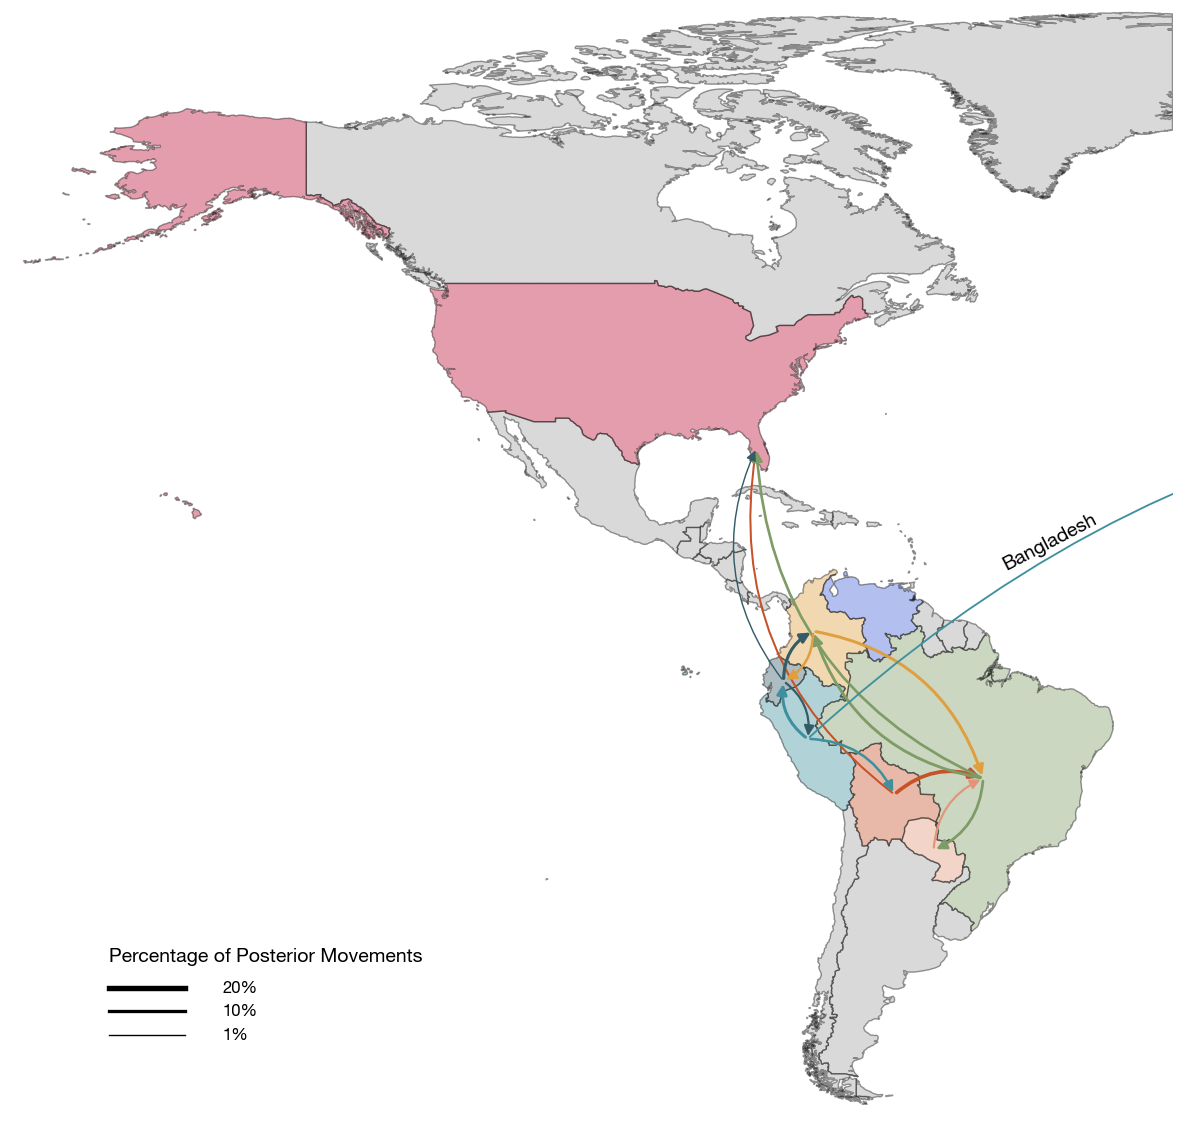

In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import cartopy

# Read the GeoJSON file
world = gpd.read_file('/DENV/2024/world-administrative-boundaries.geojson')
world['name'] = world['name'].str.replace('United States of America', 'United States')
world['name'] = world['name'].str.replace('Bolivia (Plurinational State of)', 'Bolivia')
world['name'] = world['name'].str.replace('Venezuela (Bolivarian Republic of)', 'Venezuela')



# Filter for countries in the Americas
America = world[world['name'].isin(american_countries)]

# Define the color palette
palette = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "United States": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade"
}

# Define the bounding box coordinates
minx, miny = -180, -57
maxx, maxy = -27, 84

# Create the bounding box
bbox = box(minx, miny, maxx, maxy)

# Convert the bounding box to a GeoDataFrame
bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox]}, crs="EPSG:4326")

# Clip the America GeoDataFrame with the bounding box
America_clipped = gpd.clip(America, bbox_gdf)

# Map colors based on country name
America_clipped['color'] = America_clipped['name'].map(palette)

# Handle countries without a specified color
America_clipped['color'] = America_clipped['color'].fillna('#A0A0A0')

# Define country coordinates (longitude, latitude)
country_coords = {
    "United States": (-81.760254, 	27.994402),
    "Colombia": (-74.2973, 4.5709),
    "Brazil": (-51.9253, -14.2350),
    "Peru": (-75.0152, -9.19),
    "Mexico": (-102.5528, 23.6345),
    "Ecuador": (-78.1834, -1.8312),
    "Bolivia": (-63.5887, -16.2902),
    "Central_America": (-85.2072, 15.7835),
    "Caribbean": (-77.781167, 21.52175),
    "Paraguay": (-58.4438, -23.4425),
    "Bangladesh": (90.3563, 23.6849),
    "Rest_SA" : (-66.916664, 10.500000),
    "Venezuela": (-66.5897, 6.4238)
}

# Read connections from CSV
#Replace USA with United States
MarkovJumps_map = pd.read_table('/DENV/2024/D2/F1112/NewJumpsF112.csv', sep=',', skiprows=1)
#group by "from" country and filter out those with less than 1%
connections_df = MarkovJumps_map.groupby(['from', 'to']).size()
#filter out those with less than 1% of the total number of jumps
connections_df = connections_df[connections_df > 0.01*connections_df.sum()]

connections_df = connections_df.reset_index()
connections_df.columns = ['from', 'to', 'jumps']
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')
#create percentage column
connections_df['percentage_movements'] = connections_df['jumps']/connections_df['jumps'].sum()*100
for _, row in connections_df.iterrows():
    print(f"{row['from']} → {row['to']}: {row['percentage_movements']:.2f}%")


#Print the percentage of moments from Colombia to other countries
from_colombia = connections_df[connections_df['from'] == 'Colombia']['percentage_movements'].sum()
to_colombia = connections_df[connections_df['to'] == 'Colombia']['percentage_movements'].sum()

print(f"\nTotal percentage of movements **from** Colombia: {from_colombia:.2f}%")
print(f"Total percentage of movements **to** Colombia: {to_colombia:.2f}%")


def scale_bayes_factor(x, min_val=1, max_val=20, min_width=3, max_width=350):
    # Normalize x to the [0, 1] range based on the percentage scale (min_val to max_val)
    normalized_x = (x - min_val) / (max_val - min_val)
    
    # Scale the width between min_width and max_width based on the normalized value
    scaled_width = min_width + (normalized_x * (max_width - min_width))
    
    return scaled_width

connections_df['scaled_width'] = connections_df['percentage_movements'].apply(scale_bayes_factor)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.set_facecolor('#e8f1f8')
# Plot the clipped map with the specified colors
#Set function for Alpha
# Define the alpha function based on country membership in american_countries
alpha_func = lambda x: 0.4 if x in american_countries else 1

# Apply the function to the 'name' column and create a new column 'alpha'
America_clipped['alpha'] = America_clipped['name'].apply(alpha_func)

# Plot with varying alpha values

# Generate gradient background
# Define the latitude range (from miny to maxy)
lat_range = np.linspace(miny, maxy, 100)

# Create a 2D array where each row is a color between #e2eff8 and white (along the vertical axis)
colors = np.array([np.linspace(0.886, 1, 100),  # Red channel (from #e2eff8 to white)
                   np.linspace(0.937, 1, 100),  # Green channel (from #e2eff8 to white)
                   np.linspace(0.973, 1, 100)])  # Blue channel (from #e2eff8 to white)

# Convert to 3D array (100x1x3) and transpose it to make the gradient vertical
gradient = np.dstack([colors[0], colors[1], colors[2]])


# Use imshow to plot the gradient background
from scipy import ndimage

#rotated_gradient = ndimage.rotate(gradient, -90)
#ax.imshow(rotated_gradient, aspect='auto', extent=[minx, maxx, miny, maxy], origin='lower')

America_clipped.plot(ax=ax, color=America_clipped['color'], linewidth=1, edgecolor='k', alpha=America_clipped['alpha'])



# Function to draw curved arrows with thin black edges and fill color from origin country
def draw_curved_arrow(ax, start, end, bayes_factor, color, arrowstyle='->', mutation_scale=15):
    # Calculate the midpoint for curvature
    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2
    # Adjust the curvature
    delta_x = end[0] - start[0]
    delta_y = end[1] - start[1]
    curvature = -0.3  # Adjust for more or less curvature
    if delta_x == 0 and delta_y == 0:
        curvature = 0
    # Create a FancyArrowPatch with Bezier curve
    arrow = FancyArrowPatch(
        posA=start,
        posB=end,
        connectionstyle=f"arc3,rad={curvature}",
        arrowstyle=arrowstyle,
        facecolor=color,     # Fill color from origin country
        edgecolor=color,       # Thin black edge
        linewidth=np.log10(bayes_factor),         # Thin edge line
        mutation_scale=mutation_scale,
        zorder=5
    )
    ax.add_patch(arrow)

# Iterate through connections and draw arrows
for _, row in connections_df.iterrows():
    from_country = row["from"]
    to_country = row["to"]
    percentage_movements = row["percentage_movements"]
    
    # Get coordinates
    if from_country in country_coords and to_country in country_coords:
        start_lon, start_lat = country_coords[from_country]
        end_lon, end_lat = country_coords[to_country]
        color = palette.get(from_country, 'grey')  # Use the color of the starting country or grey if not found

        scaled_width = row["scaled_width"]
        
        # Draw the curved arrow
        draw_curved_arrow(
            ax,
            start=(start_lon, start_lat),
            end=(end_lon, end_lat),
            bayes_factor=scaled_width,  # Use the bayes.factor from the connection
            color=color,                # Fill color from origin country
            arrowstyle='-|>',           # Arrow style with a filled head
            mutation_scale=15           # Size of the arrow head
        )

start_x, start_y = -75.0152, -9.19  # Coordinates where the arrow starts
end_x, end_y = 90.3563, 23.6849 # Coordinates where the arrow ends

# Calculate the angle of the arrow for the correct text inclination
angle = np.degrees(np.arctan2(end_y - start_y, end_x - start_x))

# Add the text annotation, rotated with the same inclination as the arrow
plt.text(
    (start_x - end_x) / 5-10, (start_y + end_y)*1.1,  # Midpoint of the arrow for text location
    'Bangladesh',  # The text annotation
    fontsize=14,  # Adjust the font size as needed
    rotation=angle*2.45,  # Align the text to the arrow's angle
    ha='center', va='center',  # Center the text at its location
    color='black',  # Text color, adjust if needed
)

# --- Legend ---
# Define percentages and calculate line widths
percentages = [1, 10, 20]
line_widths = [scale_bayes_factor(p, min_val=1, max_val=60, min_width=1, max_width=10) for p in percentages]

# Add legend to the plot
legend_x = maxx - 140
legend_y_start = miny + 10
for i, (perc, width) in enumerate(zip(percentages, line_widths)):
    ax.plot([legend_x, legend_x + 10], [legend_y_start + i * 3, legend_y_start + i * 3], lw=width, color='black')
    ax.text(legend_x + 15, legend_y_start + i * 3, f'{perc}%', fontsize=12, verticalalignment='center')

# Add legend title
ax.text(legend_x, legend_y_start + 10, "Percentage of Posterior Movements", fontsize=14, verticalalignment='center')

# Remove axes
plt.axis('off')

# Center the plot by setting appropriate limits
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Save the plot as high-resolution SVG and JPEG
#plt.savefig('/DENV/2024/america_map.svg', format='svg', dpi=300, bbox_inches='tight')
# plt.savefig('../Figures/america_map_F1112_phylogeography.jpeg', format='jpeg', dpi=1200, bbox_inches='tight')
# plt.savefig('../Figures/america_map_F1112_phylogeography.pdf', format='pdf', dpi=1200, bbox_inches='tight')

# Display the plot
plt.show()

In [7]:
from scipy.signal import savgol_filter
from matplotlib.lines import Line2D
from matplotlib import ticker
from matplotlib.ticker import PercentFormatter

plt.rcParams['font.family'] = 'Helvetica'

def skipped_timeseries_formatting(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    formatter = mdates.DateFormatter('%b')
    long_formatter = mdates.DateFormatter('%b\n%Y')
    accepted_months = ["Jan", "Jun"]
    labels = []
    for date in ax.get_xticks():
        formatted_date = formatter.format_data(date)
        if formatted_date in accepted_months:
            if formatted_date == "Jan":
                labels.append(long_formatter.format_data(date))
            else:
                labels.append(formatted_date)
        else:
            labels.append("")
    ax.set_xticklabels(labels)
    
COLOR = '#343434'
# Define mrsd and load data
mrsd = 2024.62

connections_df = pd.read_table('/DENV/2024/D2/F1112/NewJumpsF112.csv', sep=',', skiprows=1)

# Convert 'time' to decimal and then to date
connections_df['time'] = pd.to_numeric(connections_df['time'], errors='coerce')
connections_df['time'] = mrsd - connections_df['time']
connections_df = connections_df[connections_df['time'] >= 2012]
connections_df['time'] = connections_df['time'].round(2)
connections_df['time'] = connections_df['time'].apply(decimal_year_to_date)  # Convert to date

# Filter outliers in time
connections_df = connections_df[connections_df['time'] >= pd.Timestamp('2018-01-01')]

# Replace 'USA' with 'United States'
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')

# Create the 'movement' column
connections_df["movement"] = connections_df["from"].str.capitalize() + "To" + connections_df["to"].str.capitalize()

# Calculate total number of movements and filter out those less than 1%
total_movements = len(connections_df)
movement_counts = connections_df["movement"].value_counts()
threshold = total_movements * 0.01
valid_movements = movement_counts[movement_counts >= threshold].index
filtered_df = connections_df[connections_df["movement"].isin(valid_movements)].copy()

# Filter for Colombia
jumps = filtered_df[filtered_df["to"] == "Colombia"].copy()
location = "Colombia"

# Create pivot table for plotting
sd_jumps = jumps.loc[(jumps["from"] == location) | (jumps["to"] == location)].copy()
sd_jumps.loc[sd_jumps["to"] == location, "to"] = sd_jumps["from"]
sd_jumps["from"] = location
plot_df = sd_jumps.pivot_table(index="time", columns="to", values="from", aggfunc="count", fill_value=0)
plot_df = plot_df.apply(lambda x: savgol_filter(x, window_length=min(31, len(x)), polyorder=3))
plot_df = plot_df.clip(lower=0)
plot_df = plot_df.apply(lambda x: x / x.sum(), axis=1)
plot_df = plot_df.reindex(columns=sd_jumps["to"].value_counts().sort_values().index)

jumps_mag = sd_jumps.pivot_table(index="time", values="from", aggfunc="count", fill_value=0)
jumps_mag["from"] = savgol_filter(jumps_mag["from"], window_length=min(31, len(jumps_mag)), polyorder=3)
jumps_mag = jumps_mag / jumps_mag.max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 5), dpi=1200, nrows=2, sharex=True,
                       gridspec_kw={"height_ratios": (0.2, 1), "hspace": 0.05})
ax[0].plot(jumps_mag.index, jumps_mag["from"], color=COLOR, zorder=9)
ax[0].fill_between(jumps_mag.index, jumps_mag["from"], color=COLOR, alpha=0.8, zorder=8)

# Handle column types
try:
    plot_df.columns = pd.to_datetime(plot_df.columns).floor('D')
except ValueError:
    pass

# Plot stackplot
ax[1].stackplot(plot_df.index, plot_df.T, labels=plot_df.columns, zorder=9,
                colors=[palette[i] for i in plot_df.columns], alpha=0.7, linewidth=2)

baseline = np.zeros(len(plot_df))
for i in plot_df:
    if i != plot_df.columns[-1]:
        ax[1].plot(plot_df.index, plot_df[i] + baseline, color=COLOR, zorder=10, linewidth=1)
        baseline += plot_df[i]

legend = []
for col in reversed(plot_df.columns):
    legend.append(Line2D([0], [0], linestyle='none', marker='s', color=palette[col] + "7F", markeredgecolor="black", label=col, markersize=12.5))

ax[0].legend(handles=legend, loc="upper center", bbox_to_anchor=(0, 0, 1, 1.55), handletextpad=0.1, frameon=False, fontsize=11, ncol=len(legend))

# Format and display plot
basic_formatting(ax[1], spines=["bottom"], which="both", xlims=(pd.to_datetime("2018-01-01"), pd.to_datetime("2024-09-01")),
                 ylims=(0, 1), ylabel="Percentage of Markov jumps", xsize=12.5, ysize=12.5)
skipped_timeseries_formatting(ax[1])
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax[1].tick_params(axis="y", pad=2.5)

basic_formatting(ax[0], spines=["bottom"], which="both", ylims=(0, 1.05), ylabel="Density", ysize=12.5, xsize=12.5)
skipped_timeseries_formatting(ax[0])
ax[0].set_yticks([0, 1])
ax[0].set_yticklabels([])
ax[0].label_outer()

plt.tight_layout()
# plt.savefig('../Figures/F1112_MarkovJumps_all.jpeg', format='jpeg', dpi=1200, bbox_inches='tight')
plt.show

/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_27020/1779723175.py:81: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plot_df.columns = pd.to_datetime(plot_df.columns).floor('D')
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_27020/1779723175.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_27020/1779723175.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_27020/1779723175.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be inco

<function matplotlib.pyplot.show(close=None, block=None)>